# 점수 예측

학습 데이터 설치

In [1]:
import os
from pathlib import Path

# Workaround for Windows OpenMP duplicate runtime crash in Jupyter.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd


In [ ]:
data_dir = Path("dataset")
csv_path = data_dir / "pbp2023.csv"

if not csv_path.exists():
    try:
        import kagglehub

        downloaded_path = Path(
            kagglehub.dataset_download(
                "szymonjwiak/nba-play-by-play-data-1997-2023",
                output_dir="dataset",
            )
        )
        csv_path = downloaded_path / "pbp2023.csv"
    except Exception as exc:
        raise FileNotFoundError(
            "dataset not found"
        ) from exc

print(f"Using dataset file: {csv_path}")


Using dataset file: dataset\pbp2023.csv


In [3]:
raw_df = pd.read_csv(csv_path, dtype={"gameid": str, "season": str})
print("rows:", len(raw_df), "| games:", raw_df["gameid"].nunique())
print("columns:", list(raw_df.columns))
raw_df.head(10)


rows: 646367 | games: 1319
columns: ['gameid', 'period', 'clock', 'h_pts', 'a_pts', 'team', 'playerid', 'player', 'type', 'subtype', 'result', 'x', 'y', 'dist', 'desc', 'season']


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season
0,0022200001,1,PT12M00.00S,0.0,0.0,NaN,0,NaN,period,start,NaN,0,0,0,Start of 1st Period (7:36 PM EST),2023
1,0022200001,1,PT12M00.00S,NaN,NaN,BOS,201143,A. Horford,Jump Ball,NaN,NaN,0,0,0,Jump Ball Horford vs. Embiid: Tip to Harris,2023
2,0022200001,1,PT11M38.00S,NaN,NaN,PHI,203954,J. Embiid,Missed Shot,Turnaround Fadeaway shot,Missed,-118,50,13,MISS Embiid 13' Turnaround Fadeaway Shot,2023
3,0022200001,1,PT11M38.00S,NaN,NaN,BOS,1627759,J. Brown,NaN,NaN,NaN,0,0,0,Brown BLOCK (1 BLK),2023
4,0022200001,1,PT11M35.00S,NaN,NaN,PHI,200782,P. Tucker,Rebound,Unknown,NaN,0,0,0,Tucker REBOUND (Off:1 Def:0),2023
5,0022200001,1,PT11M35.00S,NaN,NaN,PHI,200782,P. Tucker,Turnover,Out of Bounds Lost Ball Turnover,NaN,0,0,0,Tucker Out of Bounds Lost Ball Turnover (P1.T1),2023
6,0022200001,1,PT11M15.00S,2.0,0.0,BOS,203935,M. Smart,Made Shot,Driving Floating Bank Jump Shot,Made,120,55,13,Smart 13' Driving Floating Bank Jump Shot (2 PTS),2023
7,0022200001,1,PT11M05.00S,NaN,NaN,PHI,202699,T. Harris,Missed Shot,Driving Floating Jump Shot,Missed,50,135,14,MISS Harris 14' Driving Floating Jump Shot,2023
8,0022200001,1,PT11M05.00S,NaN,NaN,PHI,202699,T. Harris,Rebound,Unknown,NaN,0,0,0,Harris REBOUND (Off:1 Def:0),2023
9,0022200001,1,PT11M03.00S,2.0,2.0,PHI,202699,T. Harris,Made Shot,Tip Layup Shot,Made,0,0,0,Harris Tip Layup Shot (2 PTS),2023


## 데이터 전처리

전처리 함수 정의

In [4]:
import re
from typing import Dict

import torch

In [5]:
_CLOCK_PATTERN = re.compile(r"^PT(?:(\d+)M)?(\d+(?:\.\d+)?)S$")

NUMERIC_FEATURE_COLUMNS = [
    "elapsed_game_sec",
    "period",
    "clock_sec_remaining",
    "current_home_points",
    "current_away_points",
]
TARGET_COLUMNS = ["remaining_home_points", "remaining_away_points"]

In [6]:
def parse_clock_to_sec(clock: str) -> float:
    if pd.isna(clock):
        return 0.0

    match = _CLOCK_PATTERN.match(str(clock).strip())
    if match is None:
        raise ValueError(f"Unexpected clock format: {clock}")

    minutes = float(match.group(1) or 0.0)
    seconds = float(match.group(2))
    return minutes * 60.0 + seconds

In [7]:
def normalize_event_type(type_raw: str, desc: str) -> str:
    type_clean = "" if pd.isna(type_raw) else " ".join(str(type_raw).split())
    if type_clean:
        return type_clean

    desc_upper = "" if pd.isna(desc) else str(desc).upper()
    if "BLOCK" in desc_upper:
        return "Block"
    if "STEAL" in desc_upper:
        return "Steal"
    return "Unknown"

In [8]:
def build_preprocessed_df(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, dtype={"gameid": str, "season": str})

    required_cols = {
        "gameid",
        "period",
        "clock",
        "h_pts",
        "a_pts",
        "type",
        "desc",
    }
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df["_row_id"] = np.arange(len(df), dtype=np.int64)

    df["period"] = pd.to_numeric(df["period"], errors="raise").astype(np.int64)
    df["clock_sec_remaining"] = df["clock"].apply(parse_clock_to_sec).astype(np.float32)

    df = df.sort_values(
        ["gameid", "period", "clock_sec_remaining", "_row_id"],
        ascending=[True, True, False, True],
    ).reset_index(drop=True)

    df["h_pts"] = pd.to_numeric(df["h_pts"], errors="coerce")
    df["a_pts"] = pd.to_numeric(df["a_pts"], errors="coerce")

    df["current_home_points"] = (
        df.groupby("gameid", sort=False)["h_pts"].ffill().fillna(0.0).astype(np.float32)
    )
    df["current_away_points"] = (
        df.groupby("gameid", sort=False)["a_pts"].ffill().fillna(0.0).astype(np.float32)
    )

    period_len = np.where(df["period"].to_numpy() <= 4, 720.0, 300.0)
    elapsed_before = np.where(
        df["period"].to_numpy() <= 4,
        (df["period"].to_numpy() - 1) * 720.0,
        4 * 720.0 + (df["period"].to_numpy() - 5) * 300.0,
    )
    df["elapsed_game_sec"] = (elapsed_before + (period_len - df["clock_sec_remaining"])).astype(
        np.float32
    )

    final_scores = (
        df.groupby("gameid", sort=False)[["current_home_points", "current_away_points"]]
        .last()
        .rename(
            columns={
                "current_home_points": "final_home_points",
                "current_away_points": "final_away_points",
            }
        )
    )
    df = df.join(final_scores, on="gameid")

    df["remaining_home_points"] = (
        df["final_home_points"] - df["current_home_points"]
    ).astype(np.float32)
    df["remaining_away_points"] = (
        df["final_away_points"] - df["current_away_points"]
    ).astype(np.float32)

    df["event_type"] = [
        normalize_event_type(type_raw=t, desc=d)
        for t, d in zip(df["type"].values, df["desc"].values)
    ]

    event_vocab = sorted(df["event_type"].unique().tolist())
    event2id = {name: idx for idx, name in enumerate(event_vocab)}
    df["event_type_id"] = df["event_type"].map(event2id).astype(np.int64)

    if df[NUMERIC_FEATURE_COLUMNS + TARGET_COLUMNS + ["event_type_id"]].isna().any().any():
        raise ValueError("NaN detected after preprocessing")

    if (df[TARGET_COLUMNS] < 0).any().any():
        raise ValueError("Remaining points must be non-negative")

    last_targets = df.groupby("gameid", sort=False)[TARGET_COLUMNS].last()
    if not (last_targets == 0).all().all():
        raise ValueError("Each game's final target must be (0, 0)")

    period_diff = df.groupby("gameid", sort=False)["period"].diff()
    if (period_diff.dropna() < 0).any():
        raise ValueError("Period should be non-decreasing within each game")

    prev_period = df.groupby("gameid", sort=False)["period"].shift(1)
    prev_clock = df.groupby("gameid", sort=False)["clock_sec_remaining"].shift(1)
    same_period_clock_violation = (df["period"] == prev_period) & (
        df["clock_sec_remaining"] > prev_clock
    )
    if same_period_clock_violation.any():
        raise ValueError("Clock should be non-increasing inside each period")

    return df


pd -> 게임 시퀀스 리스트

In [9]:
def build_game_sequences(df: pd.DataFrame) -> list[dict]:
    sequences: list[dict] = []

    for gameid, game_df in df.groupby("gameid", sort=False):
        event_type_id = torch.tensor(
            game_df["event_type_id"].to_numpy(),
            dtype=torch.long,
        )
        num_features = torch.tensor(
            game_df[NUMERIC_FEATURE_COLUMNS].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )
        targets = torch.tensor(
            game_df[TARGET_COLUMNS].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

        sequences.append(
            {
                "gameid": str(gameid),
                "event_type_id": event_type_id,
                "num_features": num_features,
                "targets": targets,
                "seq_len": int(len(game_df)),
            }
        )

    return sequences


def split_by_gameid(
    sequences,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
) -> Dict[str, list]:
    if train_ratio <= 0 or val_ratio <= 0 or train_ratio + val_ratio >= 1.0:
        raise ValueError("train_ratio and val_ratio must satisfy 0 < train, val and train+val < 1")

    seq_by_gid = {sample["gameid"]: sample for sample in sequences}
    gameids_sorted = sorted(seq_by_gid.keys(), key=lambda x: int(x))

    n_games = len(gameids_sorted)
    n_train = int(n_games * train_ratio)
    n_val = int(n_games * val_ratio)

    train_ids = gameids_sorted[:n_train]
    val_ids = gameids_sorted[n_train : n_train + n_val]
    test_ids = gameids_sorted[n_train + n_val :]

    split = {
        "train": [seq_by_gid[g] for g in train_ids],
        "val": [seq_by_gid[g] for g in val_ids],
        "test": [seq_by_gid[g] for g in test_ids],
    }

    train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)
    if train_set & val_set or train_set & test_set or val_set & test_set:
        raise ValueError("Split leakage detected: overlapping gameid")

    return split


전처리 진행

In [10]:
processed_df = build_preprocessed_df(str(csv_path))
sequences = build_game_sequences(processed_df)
splits = split_by_gameid(sequences, train_ratio=0.8, val_ratio=0.1)

base_path = "runs/train"
new_path = base_path
count = 1

# 이미 존재하는 폴더이면 숫자를 붙이며 반복
while os.path.exists(new_path):
    new_path = f"{base_path}{count}"
    count += 1

out_dir = Path(new_path)
out_dir.mkdir(parents=True, exist_ok=True)

for split_name in ["train", "val", "test"]:
    torch.save(splits[split_name], out_dir / f"{split_name}.pt")

vocab_table = (
    processed_df[["event_type", "event_type_id"]]
    .drop_duplicates()
    .sort_values("event_type_id")
)
event2id = {
    row.event_type: int(row.event_type_id)
    for row in vocab_table.itertuples(index=False)
}
id2event = {v: k for k, v in event2id.items()}

vocab_meta = {
    "event2id": event2id,
    "id2event": id2event,
    "numeric_feature_columns": NUMERIC_FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "split_game_counts": {k: len(v) for k, v in splits.items()},
}
torch.save(vocab_meta, out_dir / "vocab_meta.pt")

print("Saved:", out_dir)
print("split game counts:", vocab_meta["split_game_counts"])
print("total events:", len(processed_df))
print("total games:", processed_df["gameid"].nunique())


Saved: runs\train4
split game counts: {'train': 1055, 'val': 131, 'test': 133}
total events: 646367
total games: 1319


In [11]:
train_loaded = torch.load(out_dir / "train.pt")
val_loaded = torch.load(out_dir / "val.pt")
test_loaded = torch.load(out_dir / "test.pt")
meta_loaded = torch.load(out_dir / "vocab_meta.pt")

assert isinstance(train_loaded, list) and len(train_loaded) > 0
assert isinstance(val_loaded, list) and len(val_loaded) > 0
assert isinstance(test_loaded, list) and len(test_loaded) > 0

sample = train_loaded[0]
assert set(sample.keys()) == {"gameid", "event_type_id", "num_features", "targets", "seq_len"}
assert sample["event_type_id"].dtype == torch.long
assert sample["num_features"].dtype == torch.float32
assert sample["targets"].dtype == torch.float32
assert sample["num_features"].shape[0] == sample["seq_len"]
assert sample["targets"].shape == (sample["seq_len"], 2)

train_ids = {x["gameid"] for x in train_loaded}
val_ids = {x["gameid"] for x in val_loaded}
test_ids = {x["gameid"] for x in test_loaded}
assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

print("load/shape/split checks passed")
print("event vocab size:", len(meta_loaded["event2id"]))


load/shape/split checks passed
event vocab size: 15


Dataset / CollateFn


In [12]:
from pathlib import Path
from typing import Union

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

In [13]:
class GameSequenceDataset(Dataset):
    def __init__(self, data_source: Union[str, Path, list[dict]]):
        if isinstance(data_source, (str, Path)):
            samples = torch.load(Path(data_source))
        else:
            samples = list(data_source)

        if len(samples) == 0:
            raise ValueError("Dataset is empty")

        required_keys = {"gameid", "event_type_id", "num_features", "targets", "seq_len"}
        for idx, sample in enumerate(samples[:5]):
            if set(sample.keys()) != required_keys:
                raise ValueError(f"Sample keys mismatch at index {idx}: {sample.keys()}")

        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> dict:
        return self.samples[index]

In [14]:
def collate_game_sequences(batch: list[dict], pad_event_id: int = 0) -> dict:
    gameids = [sample["gameid"] for sample in batch]
    event_ids = [sample["event_type_id"] for sample in batch]
    num_features = [sample["num_features"] for sample in batch]
    targets = [sample["targets"] for sample in batch]

    lengths = torch.tensor([sample["seq_len"] for sample in batch], dtype=torch.long)

    event_ids_padded = pad_sequence(
        event_ids,
        batch_first=True,
        padding_value=pad_event_id,
    )
    num_features_padded = pad_sequence(
        num_features,
        batch_first=True,
        padding_value=0.0,
    )
    targets_padded = pad_sequence(
        targets,
        batch_first=True,
        padding_value=0.0,
    )

    max_len = event_ids_padded.size(1)
    valid_mask = torch.arange(max_len).unsqueeze(0) < lengths.unsqueeze(1)

    return {
        "gameid": gameids,
        "event_type_id": event_ids_padded,
        "num_features": num_features_padded,
        "targets": targets_padded,
        "lengths": lengths,
        "valid_mask": valid_mask,
    }

In [15]:

def make_dataloaders(
    processed_dir: Union[str, Path],
    batch_size: int = 8,
    shuffle_train: bool = True,
    num_workers: int = 0,
) -> dict:
    processed_dir = Path(processed_dir)

    train_ds = GameSequenceDataset(processed_dir / "train.pt")
    val_ds = GameSequenceDataset(processed_dir / "val.pt")
    test_ds = GameSequenceDataset(processed_dir / "test.pt")

    loaders = {
        "train": DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=shuffle_train,
            num_workers=num_workers,
            collate_fn=collate_game_sequences,
        ),
        "val": DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            collate_fn=collate_game_sequences,
        ),
        "test": DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            collate_fn=collate_game_sequences,
        ),
    }
    return loaders


In [16]:
loaders = make_dataloaders(processed_dir=out_dir, batch_size=4, shuffle_train=True)

first_batch = next(iter(loaders["train"]))
print("event_type_id:", first_batch["event_type_id"].shape)
print("num_features:", first_batch["num_features"].shape)
print("targets:", first_batch["targets"].shape)
print("valid_mask:", first_batch["valid_mask"].shape)
print("lengths:", first_batch["lengths"])


event_type_id: torch.Size([4, 510])
num_features: torch.Size([4, 510, 5])
targets: torch.Size([4, 510, 2])
valid_mask: torch.Size([4, 510])
lengths: tensor([471, 473, 489, 510])


### Model

In [17]:
import torch
import torch.nn as nn

In [18]:
class ScorePrediction(nn.Module):
    def __init__(
        self,
        num_event_types: int,
        num_numeric_features: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        event_emb_dim: int = 16,
        dropout: float = 0.2,
        output_size: int = 2,
    ):
        super().__init__()

        self.event_emb = nn.Embedding(num_event_types, event_emb_dim)

        input_dim = event_emb_dim + num_numeric_features
        self.lstm = nn.LSTM(
            input_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size),
        )

    def forward(self, event_type_ids, numeric_feats, lengths):
        from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

        event_e = self.event_emb(event_type_ids)
        x = torch.cat([event_e, numeric_feats], dim=-1)

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=event_type_ids.size(1),
        )

        pred = self.regressor(out)
        return pred


### Train / Validation


In [19]:
import copy
import time
import json

import torch.nn.functional as F

In [20]:
def masked_sums(preds, targets, valid_mask):
    mask = valid_mask.unsqueeze(-1).float()
    smooth_l1_sum = (F.smooth_l1_loss(preds, targets, reduction="none") * mask).sum()
    l1_sum = ((preds - targets).abs() * mask).sum()
    valid_values = int(valid_mask.sum().item()) * preds.size(-1)
    return smooth_l1_sum, l1_sum, max(valid_values, 1)

In [21]:
def run_one_epoch(model, loader, optimizer, device, grad_clip=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss_sum = 0.0
    total_l1_sum = 0.0
    total_values = 0

    for batch in loader:
        event_type_ids = batch["event_type_id"].to(device)
        numeric_feats = batch["num_features"].to(device)
        targets = batch["targets"].to(device)
        lengths = batch["lengths"].to(device)
        valid_mask = batch["valid_mask"].to(device)

        with torch.set_grad_enabled(is_train):
            preds = model(event_type_ids, numeric_feats, lengths)
            loss_sum, l1_sum, value_count = masked_sums(preds, targets, valid_mask)
            loss = loss_sum / value_count

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

        total_loss_sum += float(loss_sum.detach().item())
        total_l1_sum += float(l1_sum.detach().item())
        total_values += value_count

    return {
        "loss": total_loss_sum / max(total_values, 1),
        "mae": total_l1_sum / max(total_values, 1),
    }

In [22]:
def fit(
    model,
    loaders,
    optimizer,
    scheduler,
    device,
    epochs,
    ckpt_path,
):
    best_val_mae = float("inf")
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_metrics = run_one_epoch(model, loaders["train"], optimizer, device)
        val_metrics = run_one_epoch(model, loaders["val"], optimizer=None, device=device)

        scheduler.step(val_metrics["loss"])

        lr = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - t0
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f}, train_mae={train_metrics['mae']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}, val_mae={val_metrics['mae']:.4f} | "
            f"lr={lr:.2e} | {elapsed:.1f}s"
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_mae": train_metrics["mae"],
                "val_loss": val_metrics["loss"],
                "val_mae": val_metrics["mae"],
                "lr": lr,
            }
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(
            {
                "model_state_dict": best_state,
                "best_val_mae": best_val_mae,
            },
            ckpt_path,
        )
        print(f"Best checkpoint saved to: {ckpt_path}")

    return history

In [ ]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

batch_size = 8
loaders = make_dataloaders(processed_dir=out_dir, batch_size=batch_size, shuffle_train=True)

num_event_types = len(meta_loaded["event2id"])
num_numeric_features = len(meta_loaded["numeric_feature_columns"])

model = ScorePrediction(
    num_event_types=num_event_types,
    num_numeric_features=num_numeric_features,
    hidden_size=128,
    num_layers=2,
    event_emb_dim=16,
    dropout=0.2,
    output_size=2,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

history = fit(
    model=model,
    loaders=loaders,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=10,
    ckpt_path=str(out_dir / "best_score_prediction.pt"),
)

val_metrics = run_one_epoch(model, loaders["val"], optimizer=None, device=device)
test_metrics = run_one_epoch(model, loaders["test"], optimizer=None, device=device)

print("Final val:", val_metrics)
print("Final test:", test_metrics)

history_path = out_dir / "history.json"
history_path.write_text(json.dumps(history, indent=2), encoding="utf-8")

print("History saved to:", history_path)

device: cuda
Epoch 01/50 | train_loss=37.2818, train_mae=37.7787 | val_loss=28.3915, val_mae=28.8885 | lr=1.00e-03 | 8.8s
Epoch 02/50 | train_loss=17.7579, train_mae=18.2513 | val_loss=12.0005, val_mae=12.4918 | lr=1.00e-03 | 8.6s
Epoch 03/50 | train_loss=10.6840, train_mae=11.1737 | val_loss=8.5773, val_mae=9.0646 | lr=1.00e-03 | 8.6s
Epoch 04/50 | train_loss=9.0757, train_mae=9.5636 | val_loss=7.4069, val_mae=7.8919 | lr=1.00e-03 | 8.5s
Epoch 05/50 | train_loss=8.6573, train_mae=9.1448 | val_loss=7.2264, val_mae=7.7114 | lr=1.00e-03 | 8.5s
Epoch 06/50 | train_loss=8.4805, train_mae=8.9677 | val_loss=6.9148, val_mae=7.3986 | lr=1.00e-03 | 8.5s
Epoch 07/50 | train_loss=8.1576, train_mae=8.6438 | val_loss=6.8259, val_mae=7.3091 | lr=1.00e-03 | 8.5s
Epoch 08/50 | train_loss=8.2086, train_mae=8.6949 | val_loss=6.9362, val_mae=7.4189 | lr=1.00e-03 | 8.5s
Epoch 09/50 | train_loss=8.0485, train_mae=8.5343 | val_loss=7.4250, val_mae=7.9113 | lr=1.00e-03 | 8.5s
Epoch 10/50 | train_loss=7.9240,

### Training Curve (Loss / MAE)


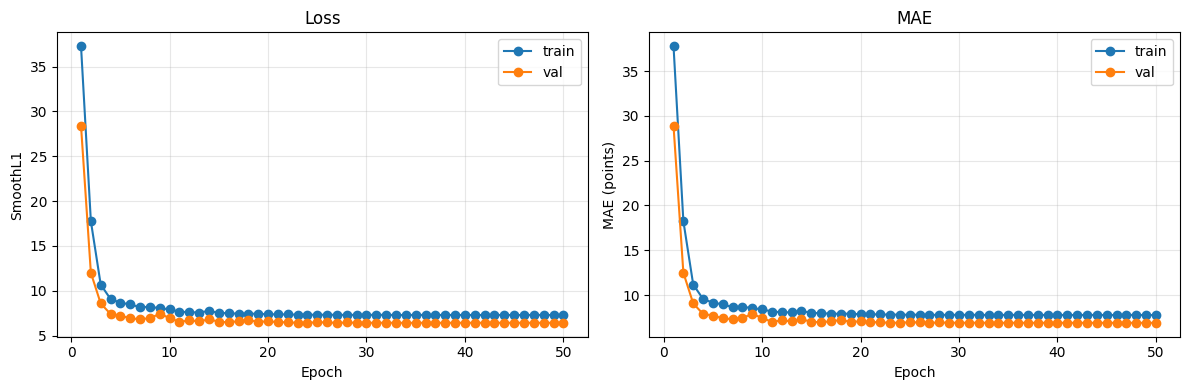

Saved: runs\train4\train_val_curves.png


In [27]:
import json

import matplotlib.pyplot as plt
import pandas as pd

history_path = out_dir / "history.json"
if history_path.exists():
    history_df = pd.DataFrame(json.loads(history_path.read_text(encoding="utf-8")))
else:
    raise FileNotFoundError("training history not found. Run training cell first.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("SmoothL1")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_mae"], marker="o", label="train")
axes[1].plot(history_df["epoch"], history_df["val_mae"], marker="o", label="val")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (points)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
curve_path = out_dir / "train_val_curves.png"
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved: {curve_path}")



### Test Set Prediction Visualization


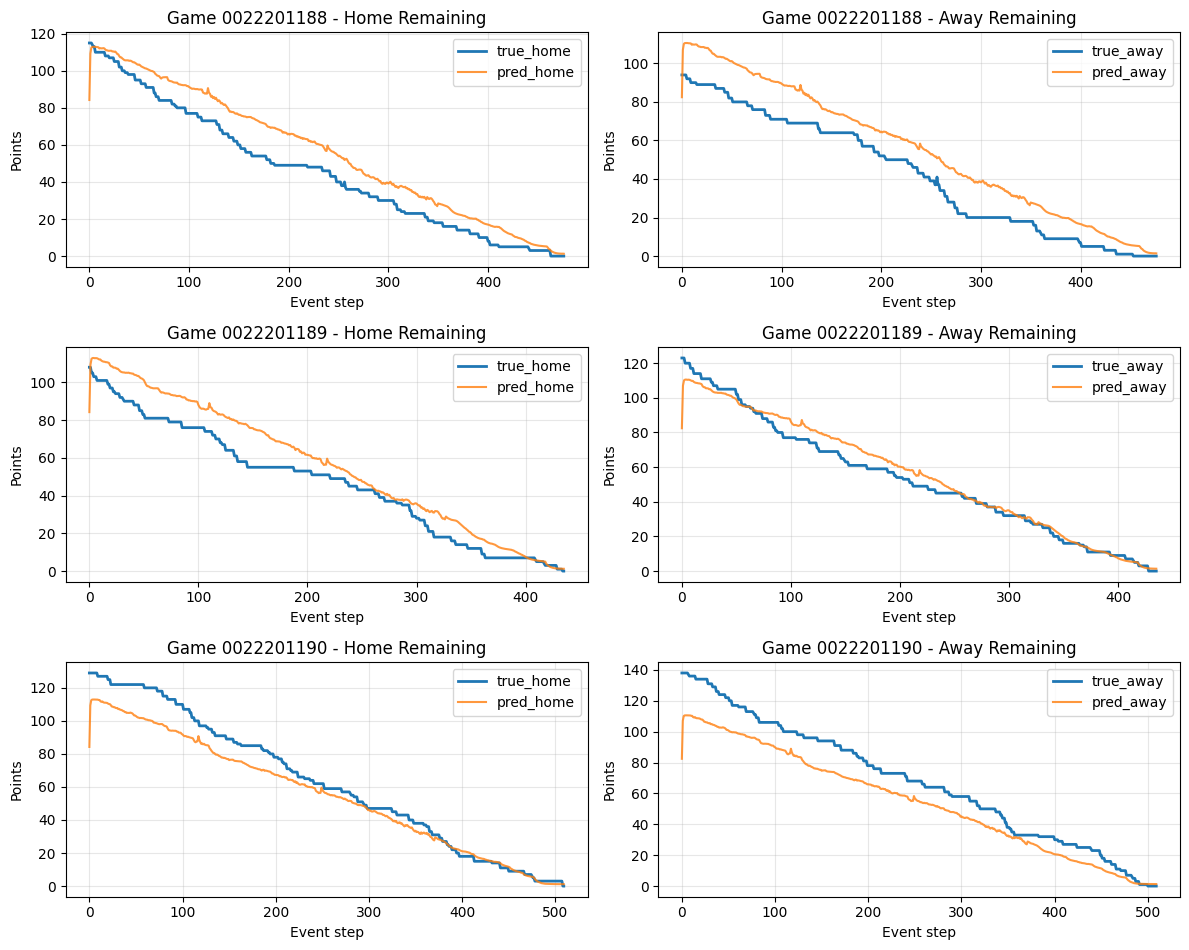

Saved: runs\train4\test_prediction_timeline.png


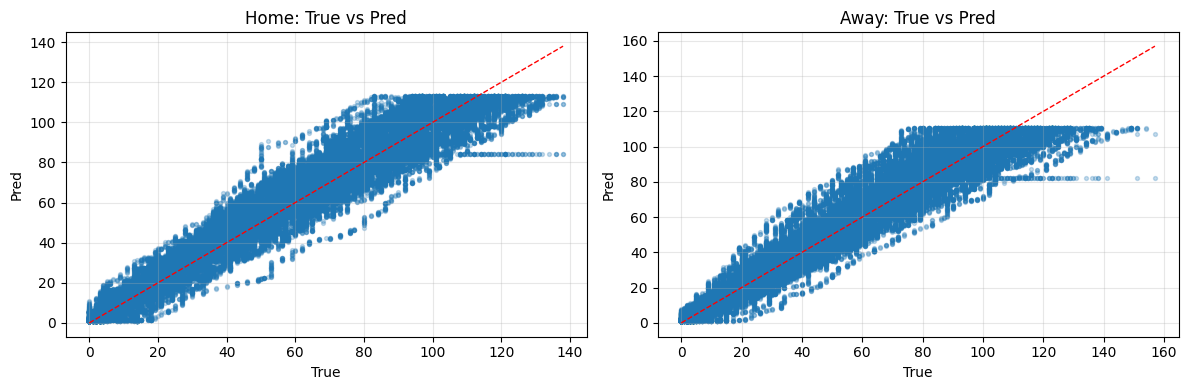

Saved: runs\train4\test_prediction_scatter.png
Test MAE - home: 6.7868, away: 7.2593, overall: 7.0230


In [28]:
import numpy as np


def collect_test_predictions(model, loader, device):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in loader:
            event_type_ids = batch["event_type_id"].to(device)
            numeric_feats = batch["num_features"].to(device)
            targets = batch["targets"].to(device)
            lengths = batch["lengths"].to(device)
            valid_mask = batch["valid_mask"].to(device)
            gameids = batch["gameid"]

            preds = model(event_type_ids, numeric_feats, lengths)

            for i, gid in enumerate(gameids):
                valid_idx = valid_mask[i].cpu().numpy().astype(bool)
                pred_np = preds[i].detach().cpu().numpy()[valid_idx]
                tgt_np = targets[i].detach().cpu().numpy()[valid_idx]

                t = np.arange(len(tgt_np))
                for step, (p, y) in enumerate(zip(pred_np, tgt_np)):
                    rows.append(
                        {
                            "gameid": gid,
                            "step": int(step),
                            "pred_home_remaining": float(p[0]),
                            "pred_away_remaining": float(p[1]),
                            "true_home_remaining": float(y[0]),
                            "true_away_remaining": float(y[1]),
                        }
                    )

    return pd.DataFrame(rows)


ckpt_path = out_dir / "best_score_prediction.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    if "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])

pred_df = collect_test_predictions(model, loaders["test"], device)
if pred_df.empty:
    raise ValueError("No predictions collected from test loader")

pred_df.to_csv(out_dir / "test_predictions.csv", index=False)

# 1) timeline plot for a few games
sample_gameids = pred_df["gameid"].drop_duplicates().head(3).tolist()
fig, axes = plt.subplots(len(sample_gameids), 2, figsize=(12, 3.2 * len(sample_gameids)), sharex=False)
if len(sample_gameids) == 1:
    axes = np.array([axes])

for r, gid in enumerate(sample_gameids):
    g = pred_df[pred_df["gameid"] == gid].sort_values("step")

    axes[r, 0].plot(g["step"], g["true_home_remaining"], label="true_home", linewidth=2)
    axes[r, 0].plot(g["step"], g["pred_home_remaining"], label="pred_home", alpha=0.8)
    axes[r, 0].set_title(f"Game {gid} - Home Remaining")
    axes[r, 0].set_xlabel("Event step")
    axes[r, 0].set_ylabel("Points")
    axes[r, 0].grid(alpha=0.3)
    axes[r, 0].legend()

    axes[r, 1].plot(g["step"], g["true_away_remaining"], label="true_away", linewidth=2)
    axes[r, 1].plot(g["step"], g["pred_away_remaining"], label="pred_away", alpha=0.8)
    axes[r, 1].set_title(f"Game {gid} - Away Remaining")
    axes[r, 1].set_xlabel("Event step")
    axes[r, 1].set_ylabel("Points")
    axes[r, 1].grid(alpha=0.3)
    axes[r, 1].legend()

plt.tight_layout()
timeline_path = out_dir / "test_prediction_timeline.png"
plt.savefig(timeline_path, dpi=150)
plt.show()
print(f"Saved: {timeline_path}")

# 2) overall scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

max_home = max(pred_df["true_home_remaining"].max(), pred_df["pred_home_remaining"].max())
max_away = max(pred_df["true_away_remaining"].max(), pred_df["pred_away_remaining"].max())

axes[0].scatter(pred_df["true_home_remaining"], pred_df["pred_home_remaining"], s=8, alpha=0.25)
axes[0].plot([0, max_home], [0, max_home], "r--", linewidth=1)
axes[0].set_title("Home: True vs Pred")
axes[0].set_xlabel("True")
axes[0].set_ylabel("Pred")
axes[0].grid(alpha=0.3)

axes[1].scatter(pred_df["true_away_remaining"], pred_df["pred_away_remaining"], s=8, alpha=0.25)
axes[1].plot([0, max_away], [0, max_away], "r--", linewidth=1)
axes[1].set_title("Away: True vs Pred")
axes[1].set_xlabel("True")
axes[1].set_ylabel("Pred")
axes[1].grid(alpha=0.3)

plt.tight_layout()
scatter_path = out_dir / "test_prediction_scatter.png"
plt.savefig(scatter_path, dpi=150)
plt.show()
print(f"Saved: {scatter_path}")

mae_home = (pred_df["pred_home_remaining"] - pred_df["true_home_remaining"]).abs().mean()
mae_away = (pred_df["pred_away_remaining"] - pred_df["true_away_remaining"]).abs().mean()
print(f"Test MAE - home: {mae_home:.4f}, away: {mae_away:.4f}, overall: {(mae_home + mae_away) / 2:.4f}")

